In [5]:
# Task 3 – K-Means Clustering
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler



In [6]:
# Load/Create Dataset and Preprocess [cite: 77]
# Simulating Mall Customer Data: Annual Income (k$) and Spending Score (1-100)
np.random.seed(42)
data = {
    'Income': np.random.randint(15, 140, 200),
    'Spending_Score': np.random.randint(1, 100, 200)
}
df = pd.DataFrame(data)

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)


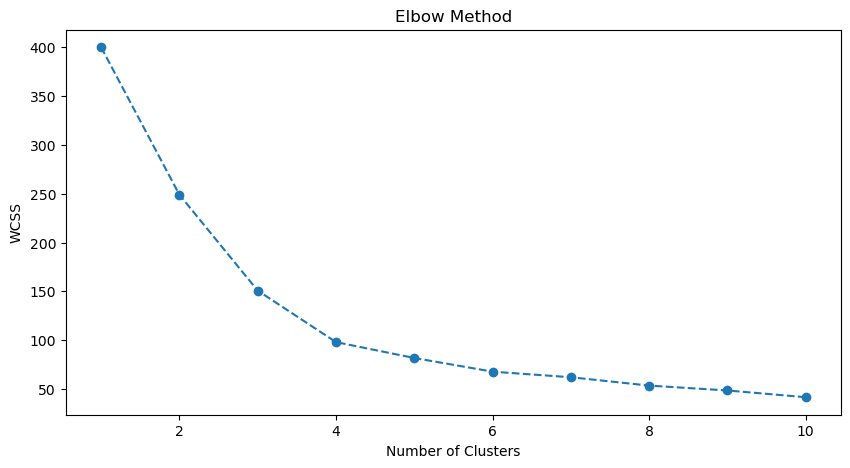

In [7]:
# Elbow Method to determine optimal clusters [cite: 78, 79]
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10,5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

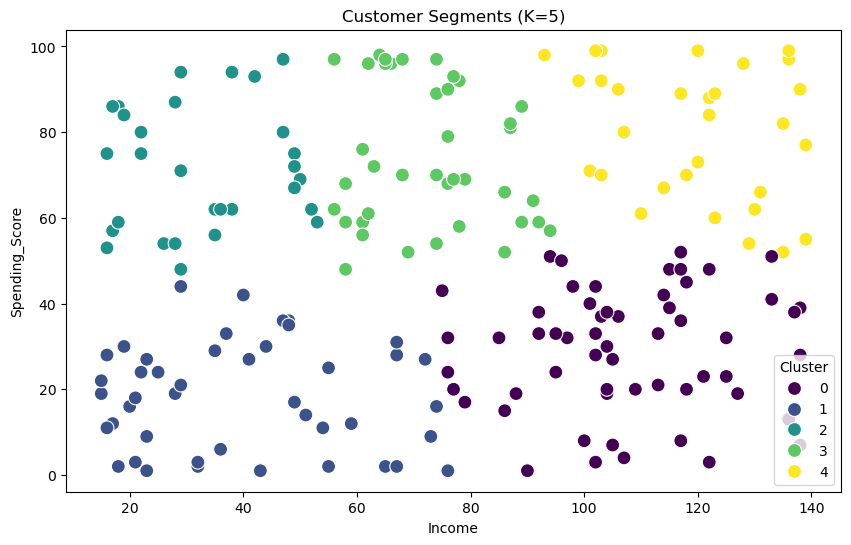

In [8]:
# Apply K-Means (Optimal Clusters = 5) [cite: 78]
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(df_scaled)
df['Cluster'] = clusters

# 4. Visualize Results [cite: 80]
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Income', y='Spending_Score', hue='Cluster', palette='viridis', s=100)
plt.title('Customer Segments (K=5)')
plt.show()